# 01 - Descarga de datos financieros

## Objetivos

En este notebook construiremos un portafolio óptimo utilizando la teoría moderna de portafolios de Harry Markowitz.

Al finalizar seremos capaces de:

1. Calcular el rendimiento esperado de un portafolio.
2. Calcular el riesgo (volatilidad).
3. Simular miles de portafolios aleatorios.
4. Encontrar el portafolio de máxima rentabilidad por unidad de riesgo (Ratio de Sharpe).
5. Encontrar el portafolio de mínima varianza.
6. Dibujar la frontera eficiente.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [32]:
from pathlib import Path

# Ruta donde se guardarán las figuras
FIGURES_DIR = Path("../reports/figures")

# Crear la carpeta si no existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
returns = pd.read_csv(
    "../data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)


## Cálculo del rendimiento esperado anual

El rendimiento esperado anual de cada activo se calcula anualizando el rendimiento promedio diario:

$
E(R_i)=\bar{r_i}\times252
$

donde:

- $E(R_i)$ es el rendimiento esperado anual del activo $i$.
- $\bar{r_i}$ es el rendimiento promedio diario.
- 252 corresponde al número aproximado de días bursátiles en un año.

Los resultados muestran que:

| Activo | Rendimiento esperado |
|--------|---------------------:|
| NVDA | 60.60 % |
| AAPL | 30.75 % |
| MSFT | 28.04 % |
| CAT | 19.34 % |
| V | 18.69 % |
| JPM | 18.62 % |
| WMT | 18.56 % |
| SPY | 14.69 % |
| XOM | 12.89 % |
| KO | 9.55 % |
| JNJ | 5.23 % |

Se observa que **NVIDIA** presenta el mayor rendimiento esperado del conjunto de activos, seguida por **Apple** y **Microsoft**. Estas compañías tecnológicas ofrecen un mayor potencial de crecimiento, aunque posteriormente se analizará si dicho rendimiento viene acompañado de un mayor nivel de riesgo.

In [19]:
# Rendimiento esperado anual

mean_returns = returns.mean() * 252

# Matriz de covarianza anual

cov_matrix = returns.cov() * 252

print(mean_returns)

AAPL    0.307545
CAT     0.193412
JNJ     0.052286
JPM     0.186224
KO      0.095536
MSFT    0.280436
NVDA    0.606041
SPY     0.146892
V       0.186925
WMT     0.185595
XOM     0.128936
dtype: float64


# Matriz de covarianza

La matriz de covarianza representa la relación existente entre las variaciones de los rendimientos de los activos.

Se calcula mediante:

$
\Sigma=
\begin{bmatrix}
\sigma_{11} & \sigma_{12} & \cdots \\
\sigma_{21} & \sigma_{22} & \cdots \\
\vdots & \vdots & \ddots
\end{bmatrix}
$

donde cada elemento se obtiene como:

$
\sigma_{ij}=Cov(R_i,R_j)
$

La diagonal principal contiene la varianza de cada activo, mientras que los elementos fuera de la diagonal representan la covarianza entre pares de activos.

Esta matriz constituye el elemento fundamental del modelo de Markowitz, ya que permite calcular el riesgo conjunto del portafolio considerando no solo la volatilidad individual de cada activo, sino también cómo interactúan entre sí.

Por ejemplo:

- NVIDIA presenta la mayor varianza individual, indicando un comportamiento significativamente más volátil.
- Microsoft y Apple muestran covarianzas relativamente altas con otros activos tecnológicos, reflejando movimientos similares del mercado.
- Activos defensivos como Coca-Cola y Johnson & Johnson presentan covarianzas menores, lo que favorece la diversificación del portafolio.

In [20]:
print(cov_matrix)

          AAPL       CAT       JNJ       JPM        KO      MSFT      NVDA  \
AAPL  0.093308  0.038021  0.021198  0.038159  0.023158  0.064371  0.093299   
CAT   0.038021  0.100938  0.021106  0.058568  0.023736  0.036389  0.061428   
JNJ   0.021198  0.021106  0.038277  0.022898  0.020615  0.021477  0.016974   
JPM   0.038159  0.058568  0.022898  0.087561  0.028073  0.037704  0.053075   
KO    0.023158  0.023736  0.020615  0.028073  0.038216  0.023120  0.020023   
MSFT  0.064371  0.036389  0.021477  0.037704  0.023120  0.083443  0.098989   
NVDA  0.093299  0.061428  0.016974  0.053075  0.020023  0.098989  0.265607   
SPY   0.046282  0.039878  0.019639  0.040959  0.022722  0.046311  0.069180   
V     0.047841  0.041851  0.021964  0.046664  0.026444  0.049308  0.067930   
WMT   0.022559  0.016500  0.016443  0.016651  0.016437  0.023482  0.027620   
XOM   0.028688  0.056810  0.018629  0.051745  0.024289  0.024495  0.034317   

           SPY         V       WMT       XOM  
AAPL  0.046282  

# Generación de pesos aleatorios

Cada portafolio se representa mediante un vector de pesos:

$
w=
\begin{bmatrix}
w_1,w_2,\ldots,w_n
\end{bmatrix}
$

cumpliendo la restricción

$
\sum_{i=1}^{n}w_i=1
$

donde:

- $w_i$ representa la proporción del capital invertida en cada activo.
- La suma de todos los pesos debe ser igual al 100 % del capital disponible.

En esta etapa se generan pesos aleatorios normalizados, los cuales servirán posteriormente para construir miles de combinaciones posibles de inversión durante la simulación de Monte Carlo.

In [15]:
num_assets = len(mean_returns)

weights = np.random.random(num_assets)

weights = weights / np.sum(weights)

weights


array([0.16640941, 0.1734183 , 0.0142425 , 0.04348776, 0.11669045,
       0.00968426, 0.14865638, 0.14949696, 0.02739571, 0.05698725,
       0.09353102])

# Rendimiento esperado del portafolio

El rendimiento esperado del portafolio se obtiene mediante:

$
E(R_p)=w^TR
$

o de forma equivalente,

$
E(R_p)=\sum_{i=1}^{n}w_iE(R_i)
$

donde:

- $w_i$ representa el peso del activo.
- $E(R_i)$ corresponde al rendimiento esperado anual de cada activo.

Para el portafolio generado aleatoriamente se obtuvo:

$
\boxed{E(R_p)=26.31\%}
$

Este resultado indica que, bajo la distribución actual de pesos, el portafolio tendría un rendimiento esperado anual del **26.31 %**, suponiendo que el comportamiento histórico de los activos se mantenga.

In [16]:
portfolio_return = np.dot(weights, mean_returns)

print(f"Rendimiento esperado: {portfolio_return:.2%}")

Rendimiento esperado: 24.72%


# Volatilidad del portafolio

El riesgo del portafolio se calcula mediante la expresión:

$
\sigma_p=\sqrt{w^T\Sigma w}
$

donde:

- $w$ es el vector de pesos.
- $\Sigma$ es la matriz de covarianza anual.
- $\sigma_p$ representa la volatilidad anual del portafolio.

Para el portafolio generado se obtuvo:

$
\boxed{\sigma_p=22.84\%}
$

Esta medida representa la variabilidad esperada de los rendimientos anuales y constituye el indicador de riesgo utilizado por el modelo de Markowitz.

In [17]:
portfolio_volatility = np.sqrt(
    np.dot(
        weights.T,
        np.dot(cov_matrix, weights)
    )
)

print(f"Volatilidad: {portfolio_volatility:.2%}")

Volatilidad: 22.15%


# Ratio de Sharpe

El Ratio de Sharpe mide el rendimiento obtenido por cada unidad de riesgo asumido y se calcula mediante:

$
Sharpe=\frac{E(R_p)-R_f}{\sigma_p}
$

donde:

- $E(R_p)$ es el rendimiento esperado del portafolio.
- $R_f$ es la tasa libre de riesgo.
- $\sigma_p$ corresponde a la volatilidad del portafolio.

Considerando una tasa libre de riesgo del **2 % anual**, el resultado obtenido fue:

$
\boxed{Sharpe=1.06}
$

Un Ratio de Sharpe superior a 1 generalmente se considera un buen resultado, ya que indica que el portafolio genera un rendimiento adicional adecuado respecto al riesgo asumido.

No obstante, este portafolio corresponde únicamente a una combinación aleatoria de activos. En la siguiente sección se simularán miles de portafolios para identificar aquel que maximice el Ratio de Sharpe y construir la frontera eficiente de Markowitz.

In [18]:
risk_free_rate = 0.02

sharpe_ratio = (
    portfolio_return - risk_free_rate
) / portfolio_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: 1.03


## Simulacion 10000 portafolios
Genera 10.000 portafolios diferentes con una simulación de Monte Carlo

Para cada uno calcula:

- Rendimiento esperado
- Riesgo
- Ratio de Sharpe

In [21]:
# Número de portafolios a simular

num_portfolios = 10000

# Matriz donde se almacenarán:
# Retorno
# Volatilidad
# Sharpe Ratio

results = np.zeros((3, num_portfolios))

# Lista para guardar los pesos de cada portafolio

weights_record = []

In [22]:
for i in range(num_portfolios):

    # Pesos aleatorios
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    weights_record.append(weights)

    # Retorno esperado
    portfolio_return = np.dot(weights, mean_returns)

    # Riesgo
    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    # Sharpe
    sharpe = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    # Guardar resultados

    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = sharpe

In [30]:
results_df = pd.DataFrame({
    "Return": results[0],
    "Volatility": results[1],
    "Sharpe": results[2]
})


# Mejor portafolio (Máximo Sharpe)

Entre los 10 000 portafolios simulados, el algoritmo encontró el portafolio con el mayor Sharpe Ratio.

### Resultados

- Rendimiento esperado: **32.10 %**
- Volatilidad: **25.32 %**
- Sharpe Ratio: **1.19**

Este portafolio ofrece la mejor compensación entre riesgo y rentabilidad dentro de las combinaciones evaluadas.

Un Sharpe Ratio superior a 1 generalmente se considera una buena relación riesgo-retorno, indicando que el rendimiento adicional obtenido compensa adecuadamente el riesgo asumido.

In [24]:
max_sharpe = results_df["Sharpe"].idxmax()

best_portfolio = results_df.loc[max_sharpe]

best_portfolio

Return        0.320957
Volatility    0.253217
Sharpe        1.188536
Name: 8586, dtype: float64

# Portafolio de mínima varianza

El portafolio de mínima varianza corresponde a la combinación de activos que minimiza el riesgo total de la inversión.

### Resultados

- Rendimiento esperado: **15.29 %**
- Volatilidad: **16.59 %**
- Sharpe Ratio: **0.80**

Aunque presenta el menor nivel de riesgo, también ofrece un rendimiento considerablemente menor.

Este tipo de portafolio suele ser atractivo para inversionistas con perfiles conservadores cuya prioridad es preservar el capital.

In [25]:
min_vol = results_df["Volatility"].idxmin()

min_portfolio = results_df.loc[min_vol]

min_portfolio

Return        0.152931
Volatility    0.165936
Sharpe        0.801100
Name: 9195, dtype: float64

# Frontera eficiente de Markowitz

La **frontera eficiente** representa el conjunto de portafolios que ofrecen el mayor rendimiento esperado para cada nivel de riesgo posible.

Cada punto del gráfico corresponde a un portafolio generado aleatoriamente con diferentes combinaciones de pesos para los activos.

En el eje horizontal se representa la volatilidad (riesgo) y en el eje vertical el rendimiento esperado.

La teoría moderna de portafolios propuesta por Harry Markowitz establece que un inversionista racional debe seleccionar únicamente portafolios ubicados sobre esta frontera, ya que cualquier portafolio por debajo ofrece menor rendimiento para el mismo riesgo.

El color de cada punto representa el **Sharpe Ratio**, indicador que mide la rentabilidad obtenida por cada unidad de riesgo asumido.

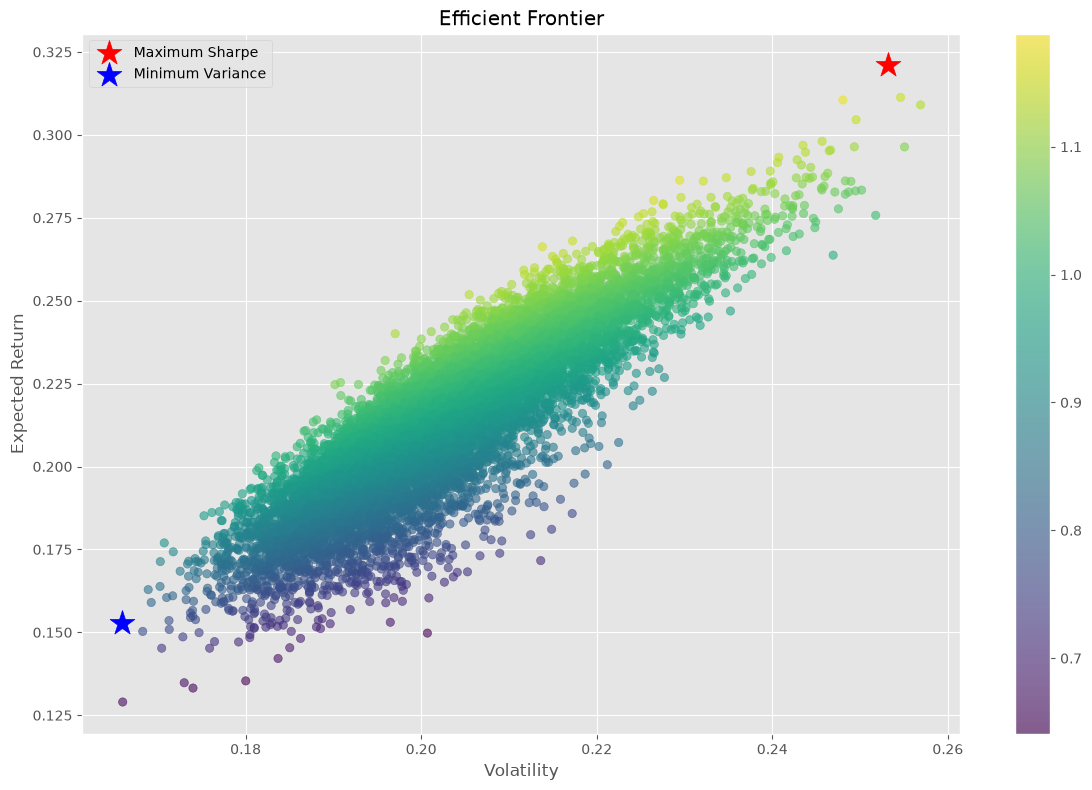

In [33]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    c=results_df["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter)

plt.scatter(
    best_portfolio["Volatility"],
    best_portfolio["Return"],
    color="red",
    marker="*",
    s=350,
    label="Maximum Sharpe"
)

plt.scatter(
    min_portfolio["Volatility"],
    min_portfolio["Return"],
    color="blue",
    marker="*",
    s=350,
    label="Minimum Variance"
)

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "efficient_frontier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Interpretación de los resultados

La simulación confirma uno de los principios fundamentales de la teoría moderna de portafolios:

- A mayor rendimiento esperado, generalmente aumenta el riesgo.
- La diversificación permite reducir parte del riesgo mediante la combinación de activos con correlaciones imperfectas.
- No siempre el activo con mayor rendimiento individual produce el mejor portafolio; la matriz de covarianzas desempeña un papel fundamental en la optimización.

El portafolio óptimo no busca maximizar únicamente la rentabilidad, sino encontrar la combinación que proporcione la mejor relación entre riesgo y rendimiento.

# Distribución óptima del portafolio

Los pesos obtenidos indican la proporción del capital que debería invertirse en cada activo para maximizar el Sharpe Ratio.

|Activo|Peso|
|------|------:|
|NVDA|31.78%|
|WMT|18.83%|
|MSFT|13.62%|
|KO|11.07%|
|CAT|9.86%|
|AAPL|4.09%|
|JNJ|4.03%|
|V|2.53%|
|SPY|1.76%|
|XOM|1.68%|
|JPM|0.75%|

El algoritmo asignó una mayor participación a **NVIDIA**, debido a su elevado rendimiento esperado durante el período analizado.

Por otro lado, activos como Walmart, Coca-Cola y Johnson & Johnson ayudan a diversificar el riesgo al presentar una menor volatilidad relativa.

La combinación final refleja el equilibrio entre crecimiento y diversificación propuesto por la teoría de Markowitz.

In [27]:
best_weights = pd.Series(
    weights_record[max_sharpe],
    index=returns.columns
)

best_weights.sort_values(ascending=False)

NVDA    0.317811
WMT     0.188270
MSFT    0.136248
KO      0.110664
CAT     0.098564
AAPL    0.040869
JNJ     0.040314
V       0.025323
SPY     0.017628
XOM     0.016806
JPM     0.007502
dtype: float64

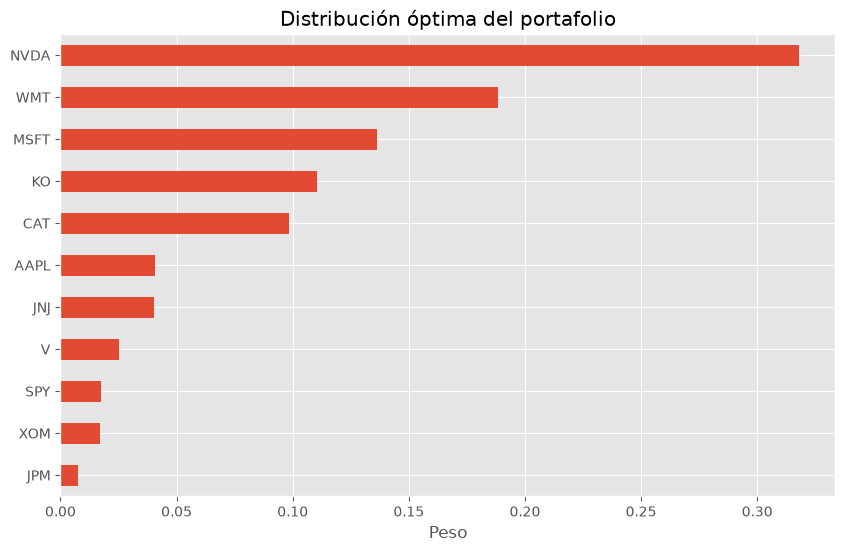

In [28]:
best_weights.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Distribución óptima del portafolio")

plt.xlabel("Peso")

plt.show()

In [31]:
print("====== PORTAFOLIO ÓPTIMO ======")

print(f"Rendimiento esperado : {best_portfolio['Return']:.2%}")

print(f"Volatilidad          : {best_portfolio['Volatility']:.2%}")

print(f"Sharpe Ratio         : {best_portfolio['Sharpe']:.2f}")

====== PORTAFOLIO ÓPTIMO ======
Rendimiento esperado : 32.10%
Volatilidad          : 25.32%
Sharpe Ratio         : 1.19
